In [1]:
import geopandas as gpd
import pandas as pd
from pysits import *
import os
from pathlib import Path

In [2]:
pontos_feijao = (
    gpd.read_file("/home/jovyan/SR_agricola/feijao/dados/amostras_pablo/pontos_feijao.shp")
    .to_crs(epsg=4326)
    .rename(columns={"classe": "label"})
    )

pontos_outros = (
    gpd.read_file("/home/jovyan/SR_agricola/feijao/dados/amostras_pablo/pontos_outros_6win.shx")
    .to_crs(epsg=4326)
    .rename(columns={"classe": "label"})
    )

print(pontos_feijao.head(), pontos_feijao.shape)
print(pontos_outros.head(), pontos_outros.shape)

    label                     geometry
0  feijao  POINT (-53.40148 -25.58492)
1  feijao  POINT (-53.40147 -25.58528)
2  feijao  POINT (-53.40108 -25.58527)
3  feijao  POINT (-53.40068 -25.58526)
4  feijao  POINT (-53.40028 -25.58525) (2296, 2)
    label                     geometry
0  outros  POINT (-53.08557 -25.64359)
1  outros  POINT (-53.08674 -25.64417)
2  outros  POINT (-53.08615 -25.64415)
3  outros  POINT (-53.08555 -25.64413)
4  outros  POINT (-53.08495 -25.64412) (12662, 2)


In [3]:
start_date = "2023-09-30"
end_date = "2024-09-29"

pontos_feijao["start_date"] = pd.to_datetime(start_date)  # ajuste ao início real da safra de feijão
pontos_feijao["end_date"] = pd.to_datetime(end_date)    # ajuste ao fim real do ciclo

pontos_outros["start_date"] = pd.to_datetime(start_date)  # ajuste ao início real da safra de feijão
pontos_outros["end_date"] = pd.to_datetime(end_date)    # ajuste ao fim real do ciclo

print(pontos_feijao.head(), pontos_feijao.shape)
print(pontos_outros.head(), pontos_outros.shape)

    label                     geometry start_date   end_date
0  feijao  POINT (-53.40148 -25.58492) 2023-09-30 2024-09-29
1  feijao  POINT (-53.40147 -25.58528) 2023-09-30 2024-09-29
2  feijao  POINT (-53.40108 -25.58527) 2023-09-30 2024-09-29
3  feijao  POINT (-53.40068 -25.58526) 2023-09-30 2024-09-29
4  feijao  POINT (-53.40028 -25.58525) 2023-09-30 2024-09-29 (2296, 4)
    label                     geometry start_date   end_date
0  outros  POINT (-53.08557 -25.64359) 2023-09-30 2024-09-29
1  outros  POINT (-53.08674 -25.64417) 2023-09-30 2024-09-29
2  outros  POINT (-53.08615 -25.64415) 2023-09-30 2024-09-29
3  outros  POINT (-53.08555 -25.64413) 2023-09-30 2024-09-29
4  outros  POINT (-53.08495 -25.64412) 2023-09-30 2024-09-29 (12662, 4)


In [4]:
roi_feijao = gpd.read_file("/home/jovyan/SR_agricola/feijao/dados/ROI_feijao/ROI.shp").to_crs(epsg=4326)

pontos_outros_dentro = gpd.sjoin(
    pontos_outros,
    roi_feijao,
    predicate="within",
    how="inner"
)

pontos_feijao_dentro = gpd.sjoin(
    pontos_feijao,
    roi_feijao,
    predicate="within",
    how="inner"
)

pontos_feijao_dentro.drop(["index_right", "id"], axis=1, inplace=True)
pontos_outros_dentro.drop(["index_right", "id"], axis=1, inplace=True)

In [5]:
pontos_treino = pd.concat(
    [pontos_feijao_dentro, pontos_outros_dentro],
    ignore_index=True
)

pontos_treino

,label,geometry,start_date,end_date
0,feijao,POINT (-53.40148 -25.58492),2023-09-30,2024-09-29
1,feijao,POINT (-53.40147 -25.58528),2023-09-30,2024-09-29
2,feijao,POINT (-53.40108 -25.58527),2023-09-30,2024-09-29
3,feijao,POINT (-53.40068 -25.58526),2023-09-30,2024-09-29
4,feijao,POINT (-53.40028 -25.58525),2023-09-30,2024-09-29
...,...,...,...,...
5528,outros,POINT (-53.13146 -25.84825),2023-09-30,2024-09-29
5529,outros,POINT (-53.13086 -25.84823),2023-09-30,2024-09-29
5530,outros,POINT (-53.13027 -25.84822),2023-09-30,2024-09-29
5531,outros,POINT (-53.12967 -25.8482),2023-09-30,2024-09-29


In [6]:
# extrai coordenadas
lon_max = pontos_treino.geometry.x.max()
lon_min = pontos_treino.geometry.x.min()
lat_max = pontos_treino.geometry.y.max()
lat_min = pontos_treino.geometry.y.min()

# define o roi para os dados de feijão
roi = {
    "lat_max": lat_max,
    "lat_min": lat_min,
    "lon_max": lon_max,
    "lon_min": lon_min,
}


pontos_treino["longitude"] = pontos_treino.geometry.x
pontos_treino["latitude"] = pontos_treino.geometry.y

pontos_treino

,label,geometry,start_date,end_date,longitude,latitude
0,feijao,POINT (-53.40148 -25.58492),2023-09-30,2024-09-29,-53.401485,-25.584915
1,feijao,POINT (-53.40147 -25.58528),2023-09-30,2024-09-29,-53.401474,-25.585276
2,feijao,POINT (-53.40108 -25.58527),2023-09-30,2024-09-29,-53.401076,-25.585266
3,feijao,POINT (-53.40068 -25.58526),2023-09-30,2024-09-29,-53.400679,-25.585256
4,feijao,POINT (-53.40028 -25.58525),2023-09-30,2024-09-29,-53.400281,-25.585246
...,...,...,...,...,...,...
5528,outros,POINT (-53.13146 -25.84825),2023-09-30,2024-09-29,-53.131460,-25.848248
5529,outros,POINT (-53.13086 -25.84823),2023-09-30,2024-09-29,-53.130863,-25.848232
5530,outros,POINT (-53.13027 -25.84822),2023-09-30,2024-09-29,-53.130265,-25.848216
5531,outros,POINT (-53.12967 -25.8482),2023-09-30,2024-09-29,-53.129668,-25.848200


<Axes: >

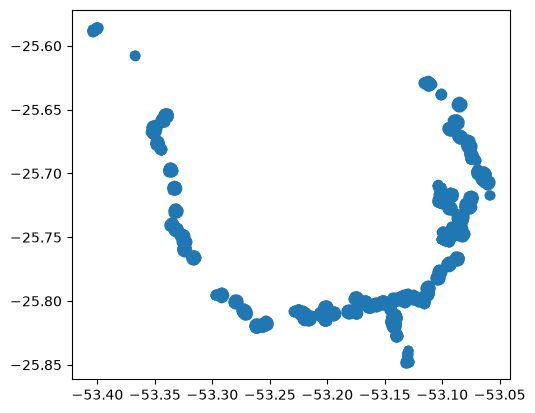

In [7]:
pontos_treino.plot()

# Definindo o cubo de dados - BDC

In [ ]:
'''# Define a data cube in the BDC repository based on the LEM ROI
bdc_cube = sits_cube(
    source = "BDC", 
    collection  = "SENTINEL-2-16D",
    bands = ("NDVI", "EVI", "B02", "B03", "B04", "B08", "B8A", "B05", "B06", "B07", "B11", "B12", "CLOUD"),
    roi = roi,
    start_date = "2023-10-01",
    end_date = "2024-04-01"
)'''

  |======================================================================| 100%


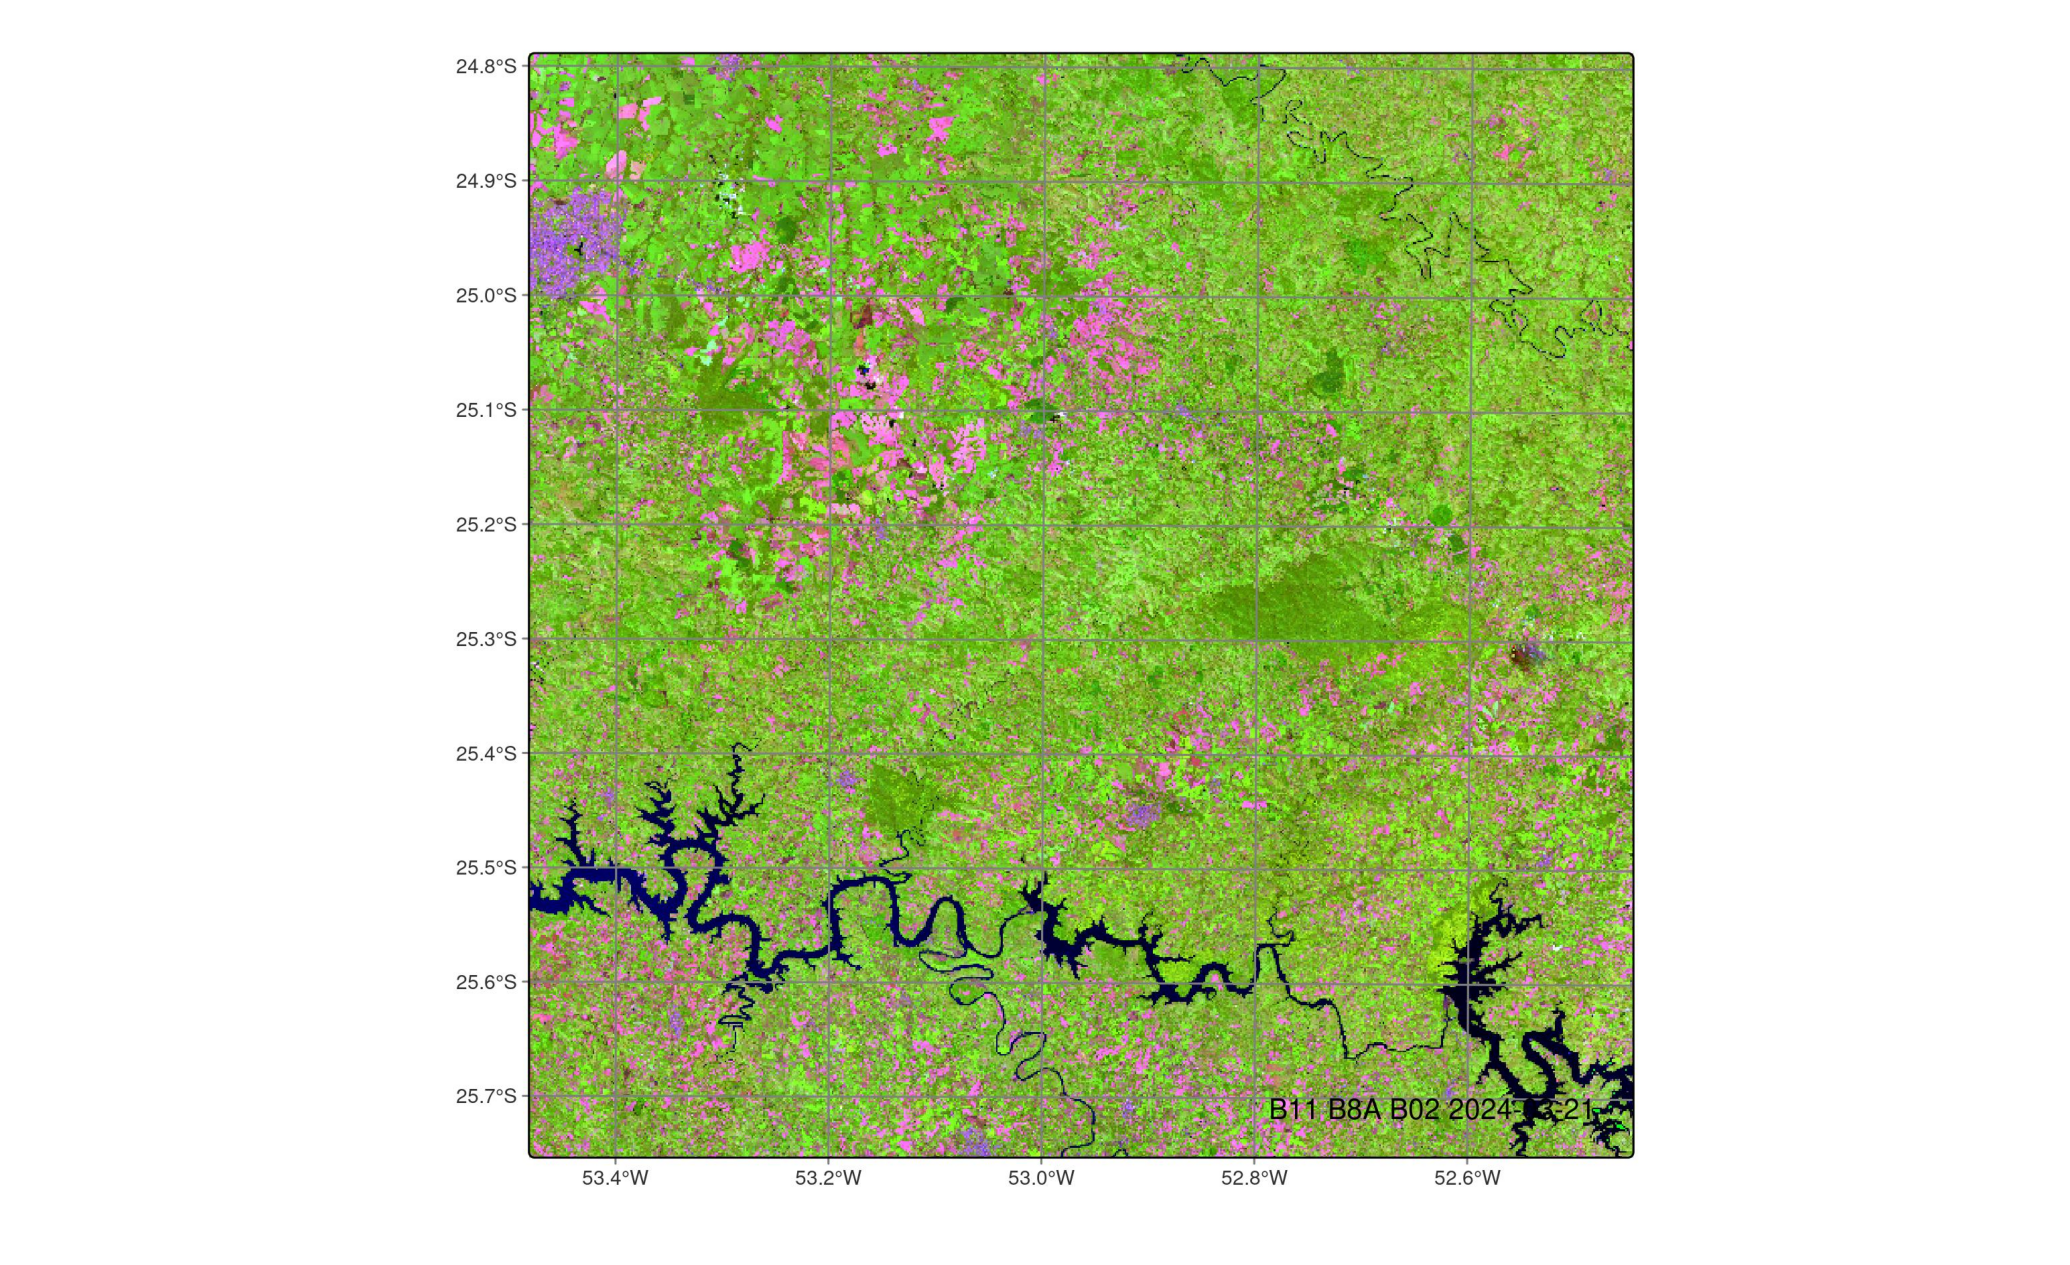

In [ ]:
'''# Plot one temporal instance
plot(bdc_cube, red = "B11", green = "B8A", blue = "B02")'''

In [ ]:
'''# criando pasta temporaria para cubo de dados regularizado
tempdir_py = Path.home() / "SR_agricola/feijao/bdc_cube_s2"
tempdir_py.mkdir(parents=True, exist_ok=True)'''

In [ ]:
'''# Copy the region of interest to a local directory
local_cube = sits_cube_copy(
    cube = bdc_cube,
    roi = roi,
    output_dir = tempdir_py
)'''

  |======================================================================| 100%


In [9]:
source_dir = "/home/jovyan/SR_agricola/feijao/bdc_cube_s2"

local_cube = sits_cube(
  source = "BDC",  # original data source, not your local directory
  collection = "SENTINEL-2-16D",
  data_dir = source_dir,
  parse_info = ["X1", "X2", "tile", "band", "date"],
  delim = "_"
)

  |======================================================================| 100%


In [10]:
samples = sits_get_data(
    cube=local_cube,
    samples=pontos_treino.drop(columns=["geometry"])
)

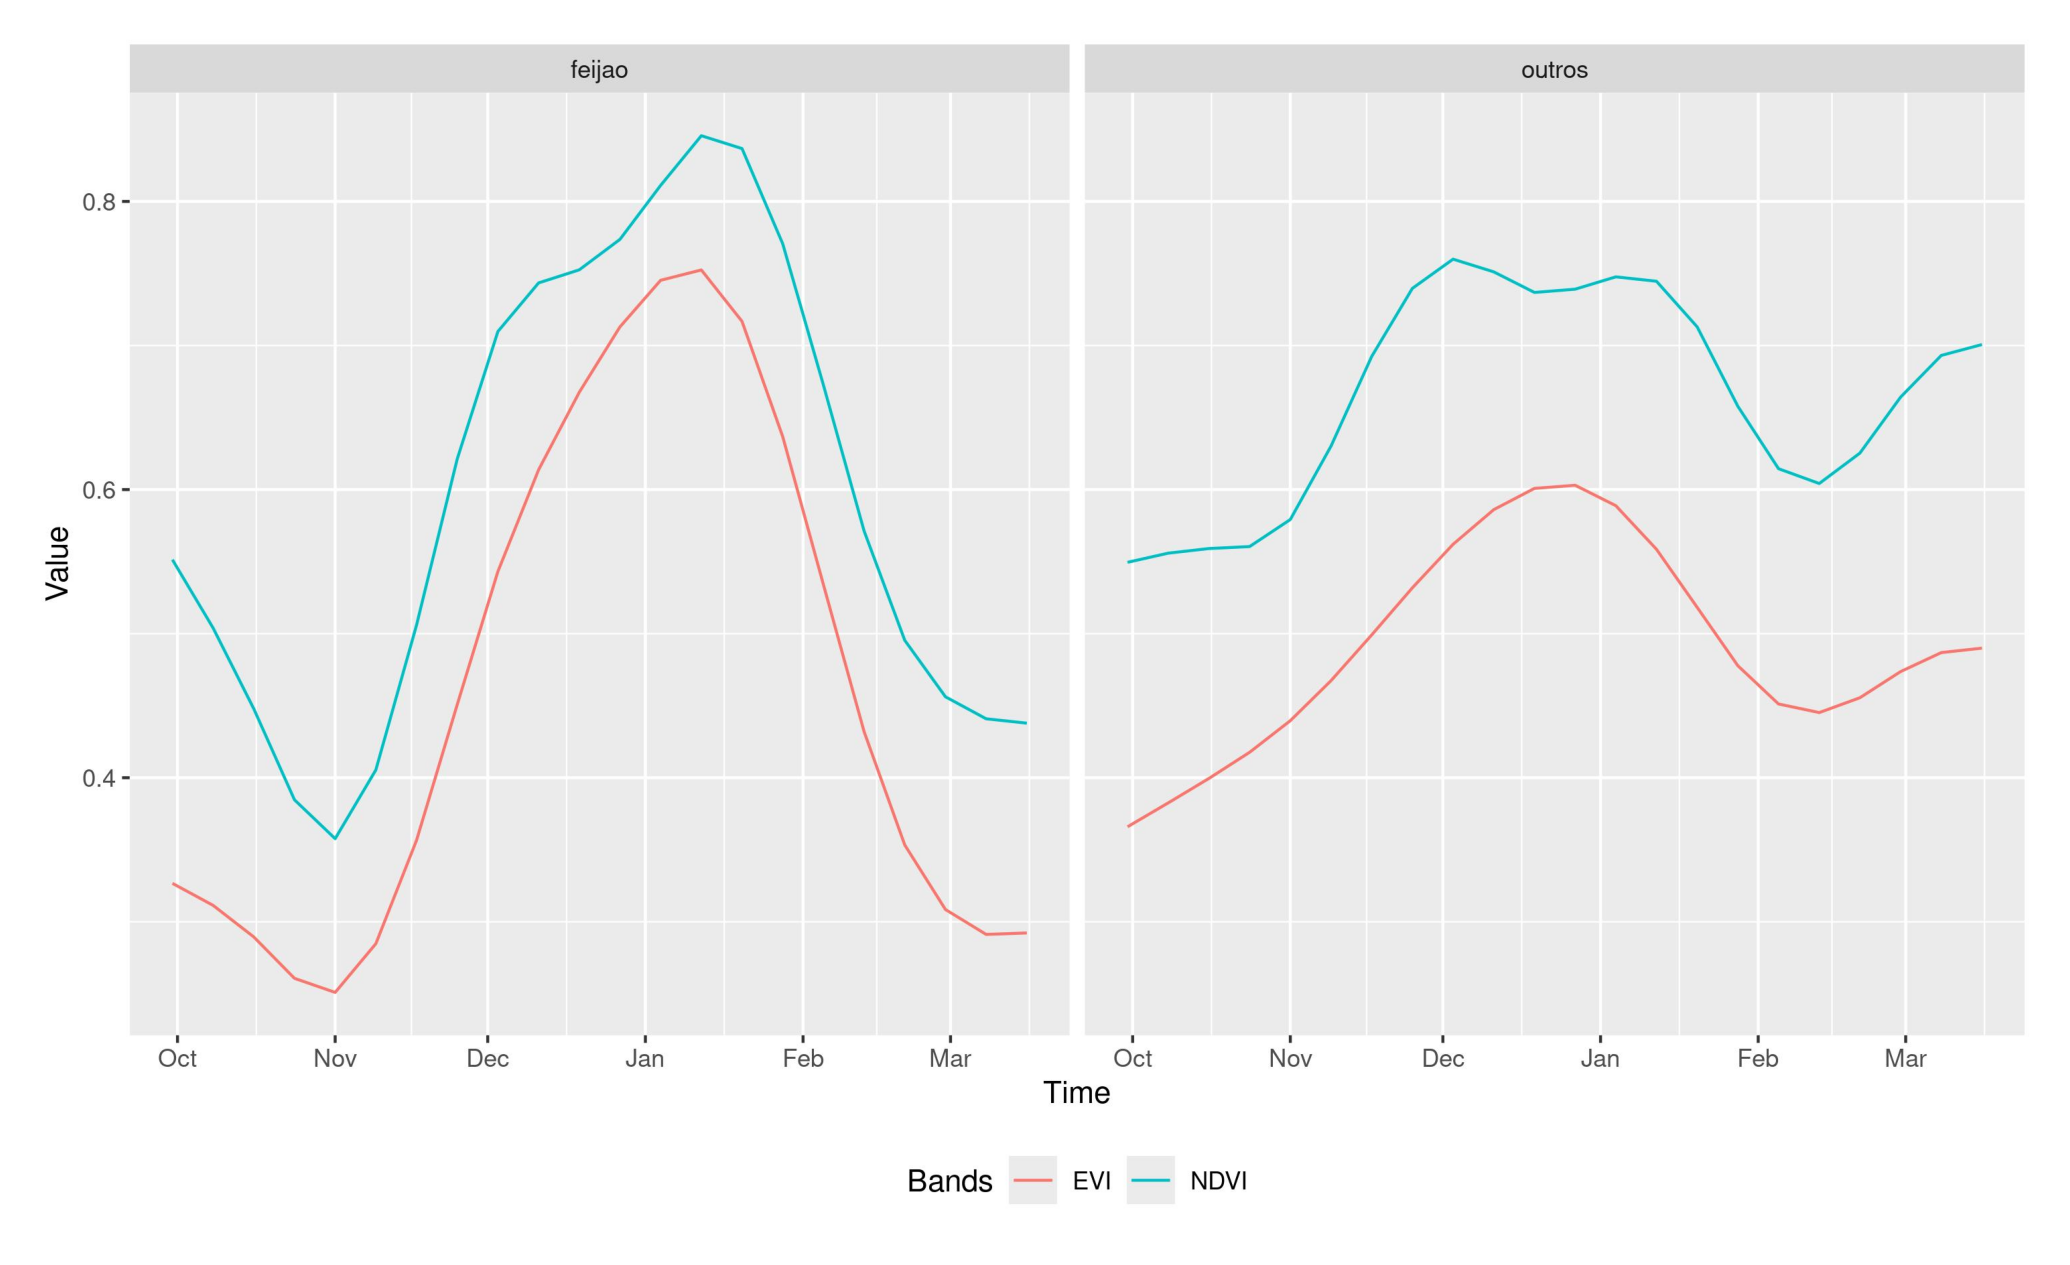

In [11]:
# Generate the temporal patterns
plot(
    sits_patterns(
        sits_select(samples, bands = ("NDVI", "EVI"))
    )
)

  |======================================================================| 100%
  |======================================================================| 100%
  |======================================================================| 100%
  |======================================================================| 100%
  |======================================================================| 100%


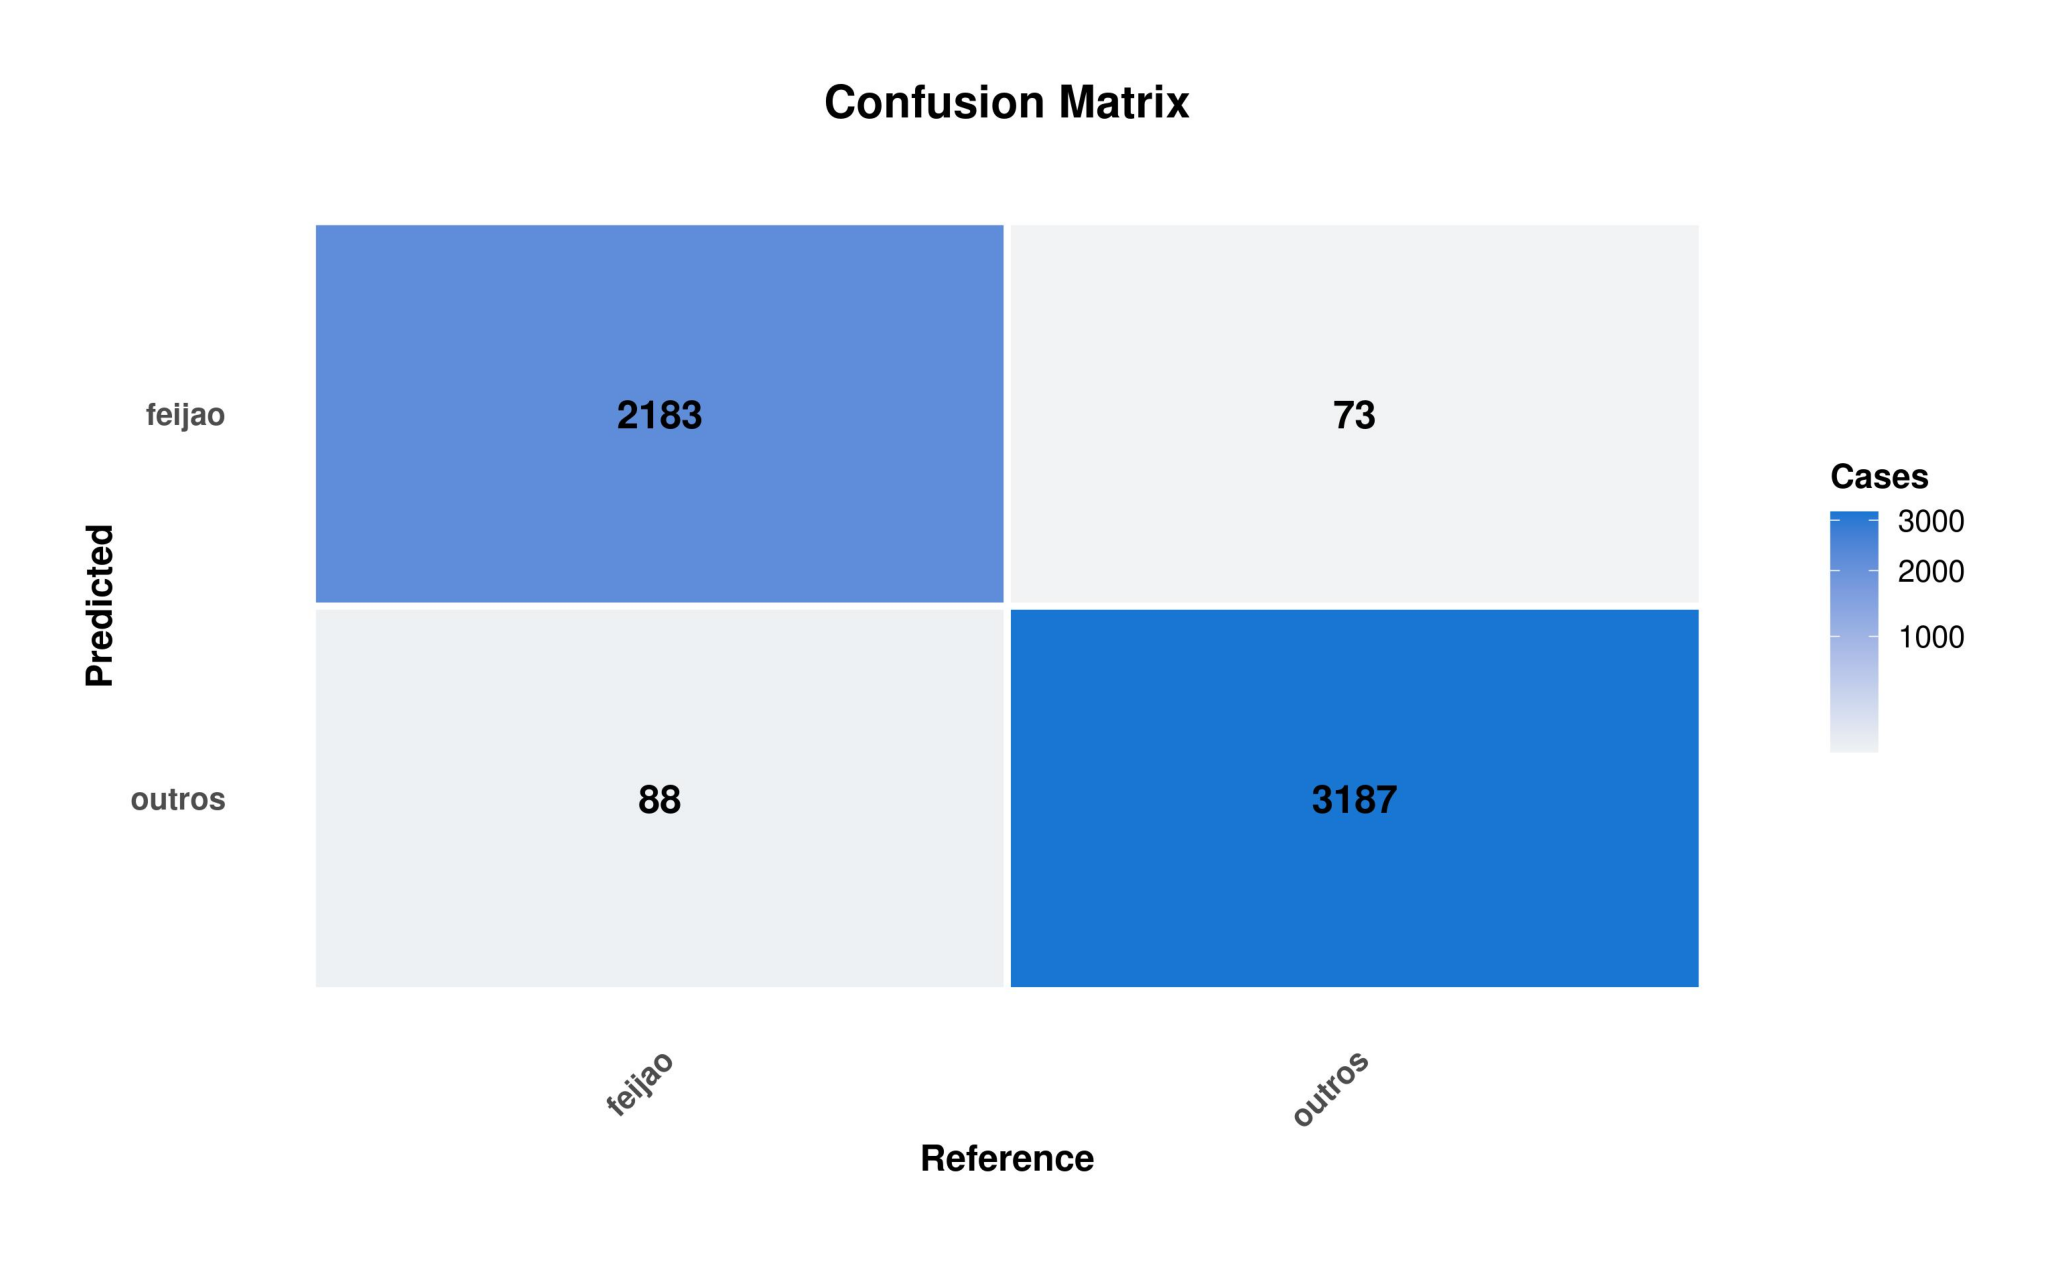

In [14]:
rfor_validate_mt = sits_kfold_validate(
    samples = samples,
    folds = 5,
    ml_method = sits_rfor(),
    multicores = 5
)
# plot the confusion matrix
plot(rfor_validate_mt, type_ = "confusion_matrix")

In [15]:
print(rfor_validate_mt)

Confusion Matrix and Statistics

          Reference
Prediction feijao outros
    feijao   2183     73
    outros     88   3187
                                      
         Accuracy : 0.9709            
           95% CI : ( 0.9661, 0.9752 )
                                      
            Kappa : 0.9398            
                                      
 Prod Acc  feijao : 0.9613            
 Prod Acc  outros : 0.9776            
 User Acc  feijao : 0.9676            
 User Acc  outros : 0.9731            
                                      



# ----------------------------

In [12]:
r_set_seed(3022024)

# Train a Random Forest model
rf_model = sits_train(
    samples = samples, 
    ml_method = sits_rfor()
)

  |======================================================================| 100%
  |======================================================================| 100%


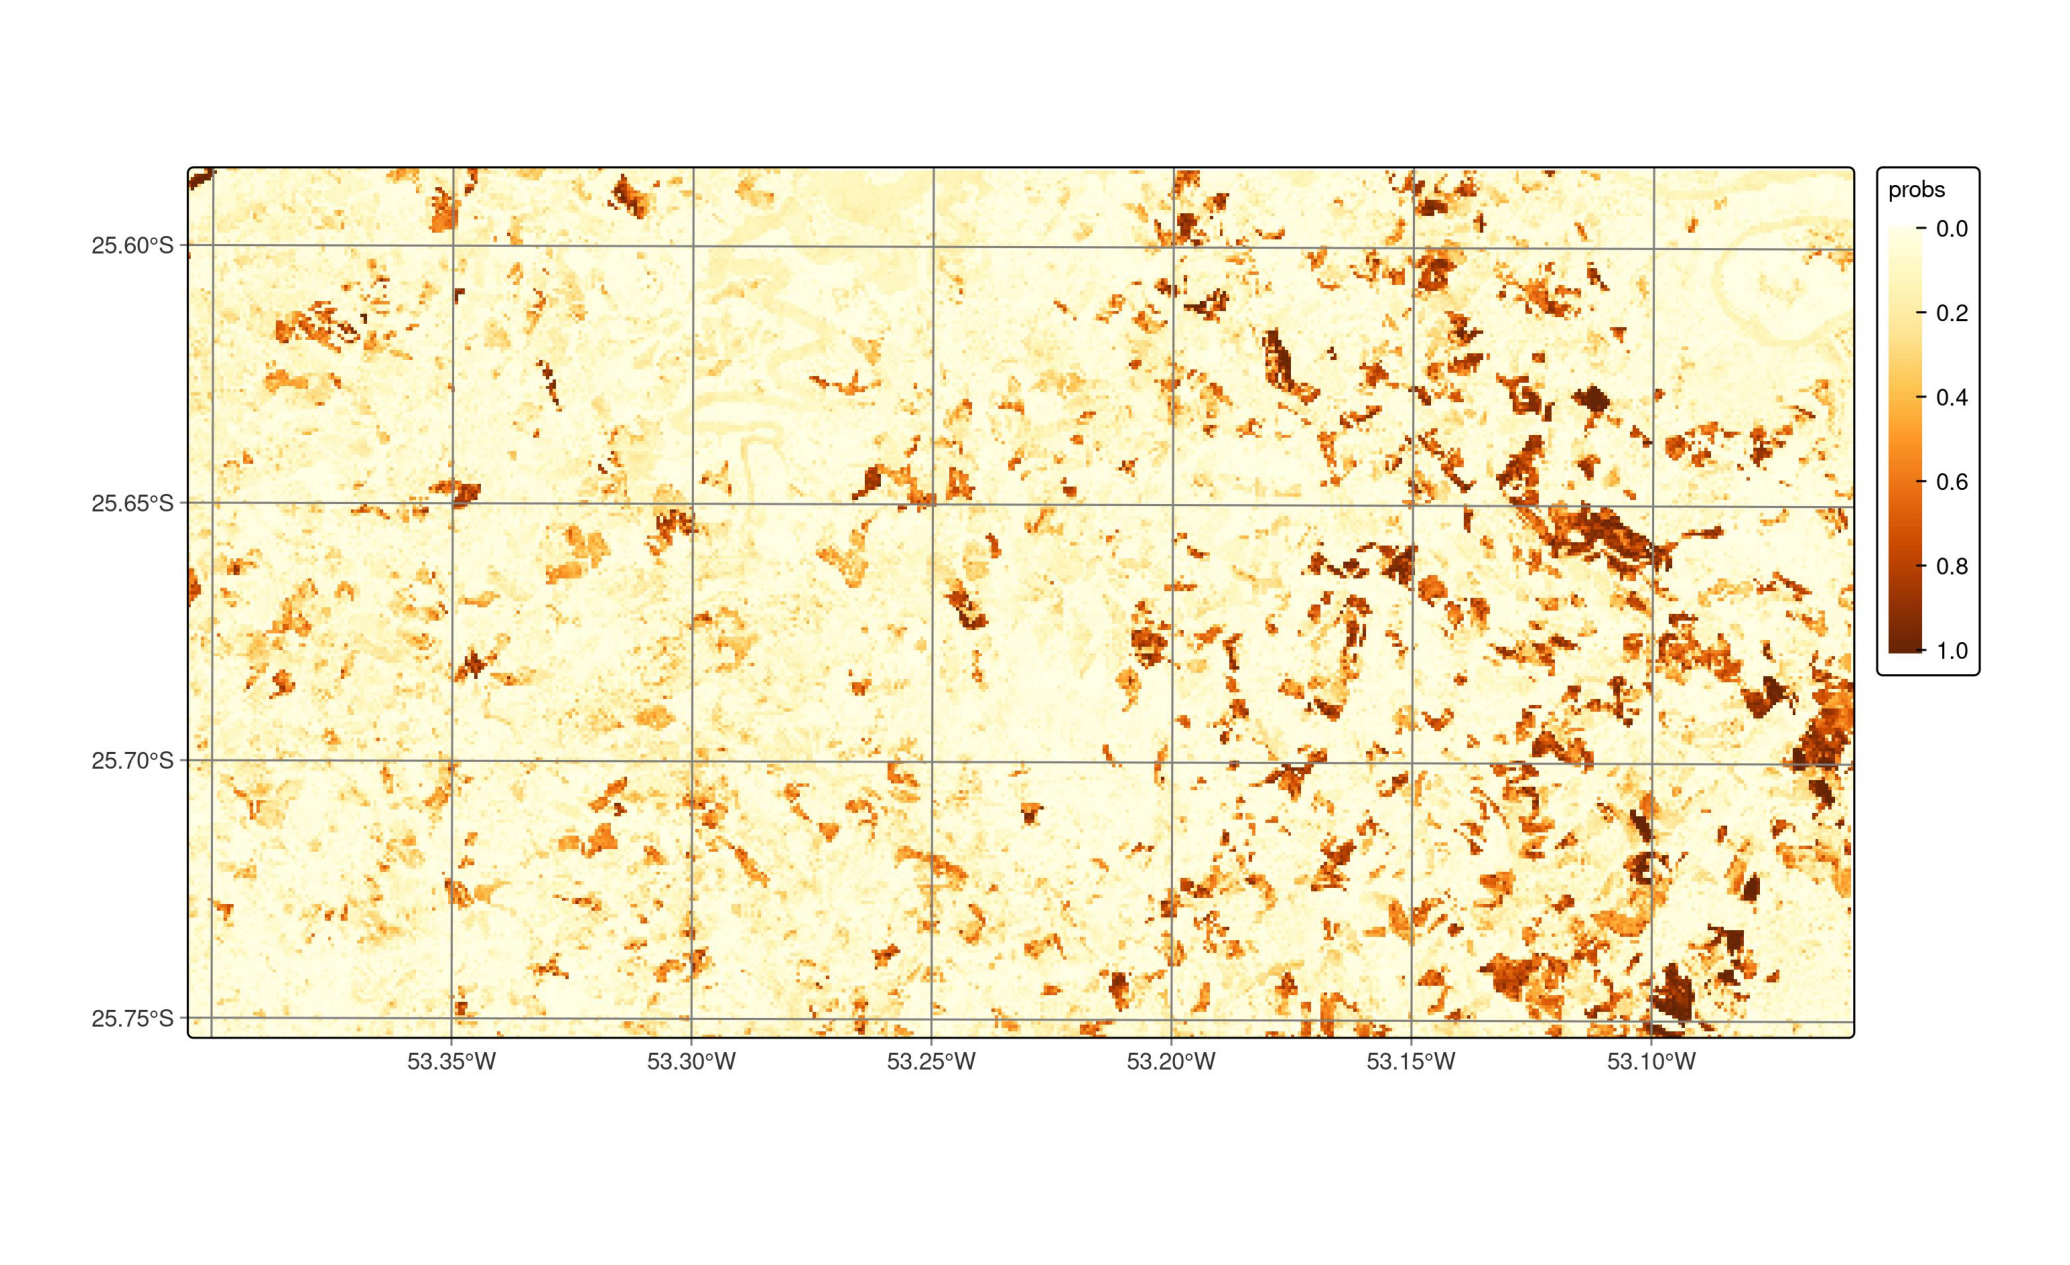

In [14]:
tempdir_py = Path.home() / "SR_agricola/feijao/sits_classify"
tempdir_py.mkdir(parents=True, exist_ok=True)

# Classify the data cube to produce a map of probabilities
lem_probs = sits_classify(
    data = local_cube, 
    ml_model = rf_model,
    multicores = 2,
    memsize = 8,
    output_dir = tempdir_py
)

# Plot the probability cube for class Forest
plot(lem_probs, labels = "feijao", palette = "YlOrBr")

In [ ]:
tempdir_py = Path.home() / "SR_agricola/feijao/sits_smooth"
tempdir_py.mkdir(parents=True, exist_ok=True)

# Smoothen a probability cube
feijao_bayes = sits_smooth(
    cube    = lem_probs,
    output_dir = tempdir_py,
    version = "rf-raster",
    multicores = 4,
    memsize = 10)

plot(feijao_bayes, labels = ("feijao"),  palette = "YlGn")

  |======================================================================| 100%
  |                                                                      |   0%

In [ ]:
tempdir_py = Path.home() / "SR_agricola/feijao/sits_label_class"
tempdir_py.mkdir(parents=True, exist_ok=True)

# Generate a thematic map
feijao_class = sits_label_classification(
    cube = feijao_bayes,
    multicores = 4,
    memsize = 10,
    output_dir = tempdir_py,
    version = "rf-raster")

# Plot the thematic map
plot(feijao_class, legend_text_size = 0.7)

# Cubo de dados sentinel2 AWS

In [ ]:

# Define a data cube in the BDC repository based on the LEM ROI
aws_cube = sits_cube(
    source = "AWS", 
    collection  = "SENTINEL-S2-L2A-COGS",
    bands = ("B02", "B03", "B04", "B08", "B8A", "B05", "B06", "B07", "B11", "B12", "CLOUD"),
    roi = roi,
    start_date = "2023-10-01",
    end_date = "2024-04-01"
)


In [ ]:
len(sits_timeline(aws_cube))

In [ ]:
plot(aws_cube, red = "B11", green = "B8A", blue = "B02")

In [ ]:
# criando pasta temporaria para cubo de dados regularizado
tempdir_py = Path.home() / "SR_agricola/feijao/dc_regularize"
tempdir_py.mkdir(parents=True, exist_ok=True)

In [ ]:
# set output dir for ARD data if it does not exist 
tempdir_py_s2 = tempdir_py / "s2"
tempdir_py_s2.mkdir(parents = True, exist_ok = True)

s2_cube_local = sits_cube_copy(
    cube = aws_cube,
    output_dir = tempdir_py_s2
)

In [ ]:
# set output dir fir regular cube if it does not exist 
tempdir_py_s2_reg = tempdir_py / "s2_reg"
tempdir_py_s2_reg.mkdir(parents = True, exist_ok = True)

# Regularize the cube to 16-day intervals
reg_cube_rondonia = sits_regularize(
          cube       = s2_cube_local,
          output_dir = tempdir_py_s2_reg,
          res        = 10,
          period     = "P16D",
          multicores = 6)

# Plot tile 20LLP of the regularized cube with the least cloud cover
# The pixels of the regular data cube cover the full MGRS tile
plot(reg_cube_rondonia, tile = "20LLP")